In [23]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)
df_DA = df[df['job_title_short']=='Data Analyst'].copy()

In [24]:
# #prepare
# df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
# df_DA['job_posted_month'] = df_DA['job_posted_date'].dt.month
# #explode
# df_DA = df_DA.explode('job_skills')
# #pivot
# df_DA_pivot = df_DA.pivot_table(index='job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)
# df_DA_pivot.loc['total'] = df_DA_pivot.sum()
# df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['total'].sort_values(ascending=False).index]
# df_DA_pivot = df_DA_pivot.drop('total')
# #convert month
# df_DA_pivot = df_DA_pivot.reset_index()
# df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
# df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
# #plot
# df_DA_pivot.iloc[:, :5].plot(
#     kind='line',
#     linewidth = 4,
#     linestyle = ':',
#     colormap = 'viridis',
#     marker = 'o',
#     markersize = 5,
#     figsize = (10, 5)
# )
# plt.title('Top 5 Skills for Data Analysts')
# plt.xlabel('')
# plt.ylabel('Counts')
# plt.show()

In [25]:
# df = df[df['job_title_short']=='Data Analyst']
# df_exploded = df.explode('job_skills')
# skill_stats = df_exploded.groupby('job_skills').agg(
#     skill_count = ('job_skills', 'count'),
#     median_salary = ('salary_year_avg', 'median')
# )
# skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)
# skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
# for i, text in enumerate(skill_stats.index):
#     plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], text)
# plt.title('Count vs. Salary of Job postings for Top 10 Skills')
# plt.ylabel('Median Yearly Salary (USD$)')
# plt.xlabel('Count of Job Postings')
# plt.tight_layout()
# plt.show()


In [26]:
from adjustText import adjust_text

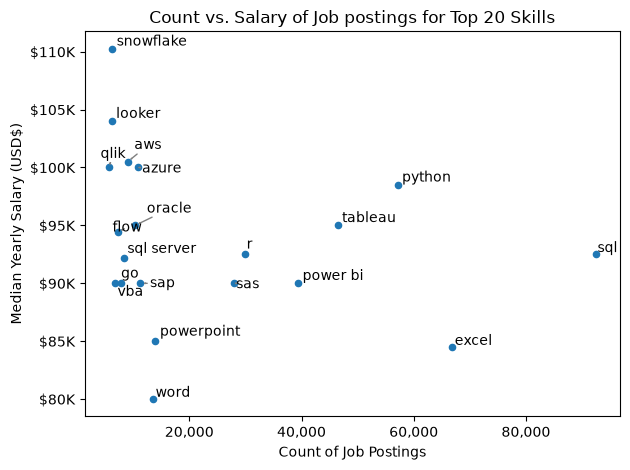

In [38]:
df = df[df['job_title_short']=='Data Analyst']
df_exploded = df.explode('job_skills')
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)
count = 20
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(count)
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
texts = []
for i, text in enumerate(skill_stats.index):
   texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], text))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))
from matplotlib.ticker import FuncFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'${y/1000:.0f}K'))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.title(f'Count vs. Salary of Job postings for Top {count} Skills')
plt.ylabel('Median Yearly Salary (USD$)')
plt.xlabel('Count of Job Postings')
plt.tight_layout()
plt.show()